# Nelkit Chavez — Individual Model Notebook
**Branch:** `student/<name>-model`

This notebook contains two architectures as required by AT3:
- **Model 1** (Phase 2): Individual architecture
- **Model 2** (Phase 3): Refined architecture based on group discussion

> **Prerequisites:** The shared `data_preparation.ipynb` must have been run at least once  
> and its outputs uploaded to the shared Google Drive folder before running this notebook.

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Install dependencies

In [45]:
!pip install -q torch torchvision nltk Pillow matplotlib rouge-score

  Preparing metadata (setup.py) ... done


## 1. Mount Google Drive & load processed data

In [29]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── Shared Drive paths (must match data_preparation.ipynb) ───────────────────
DRIVE_FOLDER    = Path('/content/drive/MyDrive/AT3-DL-ImageCaptioning')
DRIVE_PROCESSED = DRIVE_FOLDER / 'processed'
DRIVE_IMAGES    = DRIVE_PROCESSED / 'images_224'
DRIVE_CHECKPTS  = DRIVE_FOLDER / 'checkpoints'

STUDENT_NAME = 'student_name'  # <-- CHANGE THIS
MY_CHECKPTS  = DRIVE_CHECKPTS / STUDENT_NAME
MY_CHECKPTS.mkdir(parents=True, exist_ok=True)

# Verify Drive artefacts exist
for p in [DRIVE_PROCESSED / 'vocab.pkl',
          DRIVE_PROCESSED / 'splits.json',
          DRIVE_PROCESSED / 'captions_clean.json']:
    status = 'OK' if p.exists() else 'MISSING — run data_preparation.ipynb first'
    print(f'[{status}] {p.name}')

n_imgs = len(list(DRIVE_IMAGES.glob('*.jpg')))
print(f'[OK] images_224/ — {n_imgs:,} images')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] vocab.pkl
[OK] splits.json
[OK] captions_clean.json
[OK] images_224/ — 7,750 images


In [30]:
import pickle, json, random
import numpy as np

with open(DRIVE_PROCESSED / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

word2idx   = vocab['word2idx']
idx2word   = vocab['idx2word']
PAD_IDX    = vocab['PAD_IDX']
SOS_IDX    = vocab['SOS_IDX']
EOS_IDX    = vocab['EOS_IDX']
UNK_IDX    = vocab['UNK_IDX']
VOCAB_SIZE = len(word2idx)

with open(DRIVE_PROCESSED / 'splits.json') as f:
    splits = json.load(f)

with open(DRIVE_PROCESSED / 'captions_clean.json') as f:
    clean_data = json.load(f)

captions_clean = clean_data['captions']
id_to_filename = clean_data['id_to_filename']

print(f'Vocab size   : {VOCAB_SIZE:,}')
print(f'Train images : {len(splits["train"]):,}  Val: {len(splits["val"]):,}  Test: {len(splits["test"]):,}')

Vocab size   : 3,965
Train images : 6,181  Val: 772  Test: 774


## 2. Imports & device setup

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 3. Dataset & DataLoader

In [53]:
class VizWizDataset(Dataset):
    """Loads images from Drive and tokenised captions from memory."""

    # Val/test: deterministic resize → centre crop → tensor → normalise
    DEFAULT_TRANSFORM = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def __init__(self, image_ids, captions, id_to_filename, img_dir, word2idx, transform=None):
        self.samples = []
        for img_id in image_ids:
            img_id_str = str(img_id)
            fname = id_to_filename.get(img_id_str)
            if fname is None:
                continue
            for tokens in captions.get(img_id_str, []):
                indices = ([SOS_IDX]
                           + [word2idx.get(t, UNK_IDX) for t in tokens]
                           + [EOS_IDX])
                self.samples.append((img_dir / fname, indices))

        self.transform = transform or self.DEFAULT_TRANSFORM

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, caption_indices = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), torch.tensor(caption_indices, dtype=torch.long)


def collate_fn(batch):
    images, captions = zip(*batch)
    images = torch.stack(images)
    lengths = [len(c) for c in captions]
    padded = torch.zeros(len(captions), max(lengths), dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded, torch.tensor(lengths)

print('VizWizDataset and collate_fn defined.')

VizWizDataset and collate_fn defined.


In [54]:
BATCH_SIZE = 32

TRAIN_TRANSFORM = T.Compose([
    T.Resize(256),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = VizWizDataset(splits['train'], captions_clean, id_to_filename, DRIVE_IMAGES, word2idx, transform=TRAIN_TRANSFORM)
val_dataset   = VizWizDataset(splits['val'],   captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)
test_dataset  = VizWizDataset(splits['test'],  captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)

# persistent_workers=True keeps worker processes alive between epochs so the
# destructor that triggers the Python 3.12 AssertionError is never called
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True, persistent_workers=True)

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Train batches: 938  Val: 118  Test: 118


---
# Model 1 — Phase 2: CNN Encoder + LSTM Decoder

## Architecture overview

Image captioning is a **sequence-to-sequence problem** where the input is an image
and the output is a variable-length sentence. The classic solution (Show and Tell, Vinyals et al. 2015)
splits the problem into two cooperating modules:

```
Image → [Encoder CNN] → feature vector → [Decoder LSTM] → word₁, word₂, ..., <EOS>
```

### Encoder: MobileNetV3-Small (partially unfrozen)
We use MobileNetV3-Small pretrained on ImageNet. Its `features` layers extract
progressively abstract visual patterns; its `avgpool` collapses the spatial grid
into a single 576-dimensional vector. We **freeze the first 9 of 13 feature blocks**
(low-level detectors that transfer well from ImageNet) and **unfreeze the last 4**
(high-level semantics that benefit from adapting to VizWiz's noisy, real-world images).
A linear projection maps the 576-dim vector to `EMBED_SIZE=256`.

### Decoder: 1-layer LSTM
The projected image feature initialises the LSTM hidden and cell states. At each
time step the LSTM receives the embedding of the previous word and produces a
distribution over the vocabulary. During **training** we use teacher forcing
(feed the ground-truth previous word). During **inference** we use **beam search
with k=3** to find a high-probability caption without greedily committing to the
single best word at each step.

### Hyperparameters chosen
| Hyperparameter | Value | Reason |
|---|---|---|
| Embed size | 256 | Matches encoder projection; keeps decoder small |
| Hidden size | 512 | Enough capacity without exceeding Colab RAM |
| LSTM layers | 1 | Standard for captioning baselines |
| Beam width | 3 | Good BLEU/speed trade-off |
| Freeze boundary | features[0:9] frozen | Preserves low-level ImageNet features |

## 3.1 Additional imports for Model 1

We need a few utilities beyond what the boilerplate loaded:
- `heapq` — min-heap used inside beam search (stdlib, no install needed)
- `nltk.translate.bleu_score` — corpus-level BLEU metric
- `tqdm` — progress bars during training loops

In [52]:
import heapq
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm.auto import tqdm
from rouge_score import rouge_scorer

## 4. Encoder — MobileNetV3-Small

MobileNetV3-Small is made of three named sub-modules:
- `features` — 13 sequential blocks of inverted residuals + squeeze-and-excitation; outputs `(B, 576, 7, 7)`
- `avgpool` — adaptive average pool → `(B, 576, 1, 1)`
- `classifier` — two Linear layers for ImageNet classes (we discard this)

**Freeze strategy:** blocks `features[0]` through `features[8]` detect edges, textures, and basic
shapes that transfer directly from ImageNet — freezing them speeds up training and avoids
overwriting stable representations. Blocks `features[9]` through `features[12]` detect higher-level
patterns (object parts, scenes) that benefit from fine-tuning on VizWiz's noisy photography.

**Projection:** a single `Linear(576 → embed_size)` + `BatchNorm1d` + `ReLU` maps the pooled
feature to the same dimensionality that the decoder embedding layer uses, so the LSTM
receives a consistently-scaled initial state.

In [35]:
class EncoderCNN(nn.Module):
    """
    Wraps MobileNetV3-Small as a visual feature extractor.

    Forward pass:
        images  : (B, 3, 224, 224)  — normalised ImageNet tensors
        returns : (B, embed_size)   — projected feature vectors
    """

    _MOBILENET_OUT_DIM = 576  # channels after MobileNetV3-Small avgpool

    def __init__(self, embed_size: int, freeze_until: int = 9):
        """
        Args:
            embed_size   : output dim — must match DecoderLSTM's embed_size
            freeze_until : freeze features[0 : freeze_until], unfreeze the rest.
                           MobileNetV3-Small has 13 blocks (indices 0-12).
                           Default=9 keeps low-level ImageNet detectors frozen.
        """
        super().__init__()

        backbone = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )

        self.features = backbone.features  # (B,3,224,224) → (B,576,7,7)
        self.avgpool  = backbone.avgpool   # (B,576,7,7)   → (B,576,1,1)

        # Freeze early blocks (edges, textures — stable ImageNet features)
        # Unfreeze late blocks (object parts, scenes — adapt to VizWiz)
        for i, block in enumerate(self.features):
            for p in block.parameters():
                p.requires_grad = (i >= freeze_until)

        # Project 576-dim pooled vector to embed_size
        self.projection = nn.Sequential(
            nn.Linear(self._MOBILENET_OUT_DIM, embed_size),
            nn.BatchNorm1d(embed_size),
            nn.ReLU(),
        )

    def forward(self, images):
        x = self.features(images)  # (B, 576, 7, 7)
        x = self.avgpool(x)        # (B, 576, 1, 1)
        x = x.flatten(1)           # (B, 576)
        x = self.projection(x)     # (B, embed_size)
        return x


# Quick sanity check — verifies shapes without running a full forward pass
_enc_test = EncoderCNN(embed_size=256)
_frozen   = sum(p.numel() for p in _enc_test.parameters() if not p.requires_grad)
_trainable= sum(p.numel() for p in _enc_test.parameters() if p.requires_grad)
print(f'EncoderCNN  frozen params : {_frozen:,}')
print(f'EncoderCNN trainable params: {_trainable:,}')
del _enc_test

EncoderCNN  frozen params : 190,520
EncoderCNN trainable params: 884,712


## 5. Decoder — LSTM with Beam Search

### How the LSTM decoder works

Think of the decoder as a reader who has seen the image once and is now writing a caption word by word, always looking back at what they wrote last.

**Initialisation:** the encoder output (shape `(B, embed_size)`) is used to seed *both* the LSTM hidden state `h₀` and cell state `c₀` through two separate linear layers. This is the standard Show-and-Tell wiring.

**Teacher forcing (training):** we feed the ground-truth caption shifted right by one position.  
At step `t` the LSTM sees `[embed(word_{t-1})]` and predicts `word_t`.  
This makes training stable — the decoder always has a correct previous word, so errors don't compound.

**Beam search (inference):** instead of always picking the single best word, beam search keeps the `k=3` most probable *sequences* alive at each step, expands all of them, and keeps only the top-k again. At the end it returns the sequence with the highest total log-probability. This consistently produces higher BLEU scores than greedy decoding.

### Beam search internals

The heap stores tuples `(-log_prob, sequence, (h, c))` — negative because Python's `heapq` is a min-heap and we want the highest log-probability at the top. Each step:
1. Pop the best incomplete sequence.
2. Feed its last token into the LSTM → get next-word logits.
3. Take the top-k words, push k new candidates back onto the heap.
4. Stop when `<EOS>` is generated or `max_len` is reached.

In [36]:
class DecoderLSTM(nn.Module):
    """
    One-layer LSTM caption generator.

    Training  : forward(features, captions)  — teacher-forcing, returns logits
    Inference : generate(features)           — beam search, returns token list
    """

    def __init__(self, embed_size: int, hidden_size: int, vocab_size: int,
                 num_layers: int = 1, dropout: float = 0.5):
        super().__init__()

        self.hidden_size = hidden_size

        # Word embedding table: maps each token index to a dense vector
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)

        # LSTM core
        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Two linear layers to map the encoder feature → LSTM initial states
        # We need separate projections because h and c play different roles in an LSTM
        self.init_h = nn.Linear(embed_size, hidden_size)
        self.init_c = nn.Linear(embed_size, hidden_size)

        # Dropout applied to LSTM output before projection (regularisation)
        self.dropout = nn.Dropout(dropout)

        # Project hidden state to vocabulary logits
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def _init_hidden(self, features):
        """Seed LSTM states from the encoder feature vector."""
        # features: (B, embed_size)
        # LSTM expects (num_layers, B, hidden_size)
        h = self.init_h(features).unsqueeze(0)  # (1, B, hidden_size)
        c = self.init_c(features).unsqueeze(0)  # (1, B, hidden_size)
        return h, c

    def forward(self, features, captions):
        """
        Teacher-forcing forward pass used during training.

        Args:
            features : (B, embed_size)     — encoder output
            captions : (B, seq_len)        — token indices including <SOS> and <EOS>

        Returns:
            logits   : (B, seq_len-1, vocab_size)
                       Predictions for positions 1..seq_len (i.e. every word after <SOS>)
        """
        h, c = self._init_hidden(features)

        # Drop <EOS> from the input; the decoder never needs to predict what comes after EOS
        # captions[:, :-1] = [<SOS>, w1, w2, ..., w_{n-1}]
        # target (computed in training loop) = captions[:, 1:] = [w1, w2, ..., <EOS>]
        embeddings = self.embedding(captions[:, :-1])   # (B, seq_len-1, embed_size)

        out, _ = self.lstm(embeddings, (h, c))           # (B, seq_len-1, hidden_size)
        out    = self.dropout(out)
        logits = self.fc_out(out)                        # (B, seq_len-1, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, features, max_len: int = 30, beam_width: int = 3):
        """
        Beam search inference for a SINGLE image feature vector.

        Args:
            features   : (1, embed_size) — encoder output for one image
            max_len    : maximum caption length (tokens, not counting <SOS>)
            beam_width : number of candidate sequences to keep alive at each step

        Returns:
            List[int] — best token sequence (excludes <SOS>, includes <EOS> if reached)
        """
        h, c = self._init_hidden(features)  # (1, 1, hidden_size) each

        # Heap entries: (-cumulative_log_prob, token_sequence, (h, c))
        # Negative log-prob because heapq is a min-heap → lowest neg = highest prob
        initial_token = torch.tensor([[SOS_IDX]], device=features.device)
        init_emb      = self.embedding(initial_token)            # (1,1,embed_size)
        out, (h, c)   = self.lstm(init_emb, (h, c))
        log_probs     = torch.log_softmax(self.fc_out(out[:, -1, :]), dim=-1)  # (1, vocab)

        # Seed the heap with the top-beam_width tokens after <SOS>
        top_probs, top_ids = log_probs[0].topk(beam_width)
        heap = []
        for prob, tok in zip(top_probs.tolist(), top_ids.tolist()):
            heapq.heappush(heap, (-prob, [tok], (h.clone(), c.clone())))

        completed = []

        for _ in range(max_len - 1):
            if not heap:
                break

            candidates = []
            # Expand every beam candidate exactly once per step
            for _ in range(len(heap)):
                neg_prob, seq, (h_beam, c_beam) = heapq.heappop(heap)

                if seq[-1] == EOS_IDX:
                    completed.append((neg_prob, seq))
                    continue

                last_tok = torch.tensor([[seq[-1]]], device=features.device)
                emb      = self.embedding(last_tok)               # (1,1,embed_size)
                out, (h_new, c_new) = self.lstm(emb, (h_beam, c_beam))
                lp       = torch.log_softmax(self.fc_out(out[:, -1, :]), dim=-1)

                top_probs, top_ids = lp[0].topk(beam_width)
                for prob, tok in zip(top_probs.tolist(), top_ids.tolist()):
                    new_neg_prob = neg_prob - prob   # accumulate (subtract because neg)
                    candidates.append((new_neg_prob, seq + [tok], (h_new.clone(), c_new.clone())))

            # Keep only the beam_width best candidates
            candidates.sort(key=lambda x: x[0])
            heap = []
            for entry in candidates[:beam_width]:
                heapq.heappush(heap, entry)

        # Drain remaining live beams into completed
        while heap:
            neg_prob, seq, _ = heapq.heappop(heap)
            completed.append((neg_prob, seq))

        if not completed:
            return []

        # Return the sequence with the lowest negative log-prob (= highest probability)
        best = min(completed, key=lambda x: x[0])
        tokens = best[1]
        # Strip trailing <EOS> if present (cleaner for display and BLEU)
        if tokens and tokens[-1] == EOS_IDX:
            tokens = tokens[:-1]
        return tokens


# Sanity check — parameter count
_dec_test = DecoderLSTM(embed_size=256, hidden_size=512, vocab_size=3965)
_dec_params = sum(p.numel() for p in _dec_test.parameters())
print(f'DecoderLSTM total params: {_dec_params:,}')
del _dec_test

DecoderLSTM total params: 4,889,213


## 6. Hyperparameters & model instantiation

All values are documented inline. Change them here — the training loop reads from these variables.

**Why these specific values:**
- `EMBED_SIZE=256` — small enough that the full model fits in Colab RAM, large enough to express semantic similarity between words
- `HIDDEN_SIZE=512` — standard for single-layer LSTM captioners; doubles the embed to give the recurrent state more room
- `LR=3e-4` — Adam's sweet spot for mixed encoder+decoder training; lower LR for the encoder is handled via separate param groups
- `CLIP=5.0` — gradient clipping prevents exploding gradients, which are common in LSTMs on early epochs
- `ENCODER_LR_SCALE=0.1` — the unfrozen encoder blocks are already well-trained, so they need a much smaller update than the randomly-initialised decoder

In [37]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBED_SIZE       = 256
HIDDEN_SIZE      = 512
NUM_LAYERS       = 1
DROPOUT          = 0.5
EPOCHS           = 10
LR               = 3e-4
ENCODER_LR_SCALE = 0.1   # unfrozen encoder blocks train at LR * this factor
CLIP             = 5.0   # max gradient norm
BEAM_WIDTH       = 3

# ── Model instantiation ───────────────────────────────────────────────────────
encoder1 = EncoderCNN(embed_size=EMBED_SIZE).to(DEVICE)
decoder1 = DecoderLSTM(
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

# ── Separate param groups so encoder trains slower than decoder ───────────────
# The decoder is randomly initialised → needs full LR.
# The unfrozen encoder blocks are pretrained → need a gentler nudge.
encoder_params = [p for p in encoder1.parameters() if p.requires_grad]
decoder_params = list(decoder1.parameters())

optimizer1 = optim.Adam([
    {'params': encoder_params, 'lr': LR * ENCODER_LR_SCALE},
    {'params': decoder_params, 'lr': LR},
])

# Reduce LR by half when val loss stops improving for 2 epochs
# verbose was removed in PyTorch 2.x — LR changes are printed manually in the loop
scheduler1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer1, mode='min', factor=0.5, patience=2
)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

total_params = (sum(p.numel() for p in encoder1.parameters() if p.requires_grad)
                + sum(p.numel() for p in decoder1.parameters()))
print(f'Total trainable params: {total_params:,}')
print(f'Encoder trainable     : {sum(p.numel() for p in encoder_params):,}')
print(f'Decoder trainable     : {sum(p.numel() for p in decoder_params):,}')

Total trainable params: 5,773,925
Encoder trainable     : 884,712
Decoder trainable     : 4,889,213


## 7. Training loop

Each epoch does two passes:
1. **Train pass** — forward → loss → backward → clip gradients → optimizer step
2. **Val pass** — forward only (no gradients), accumulate loss

**Why `encoder1.train()` / `encoder1.eval()` matter:**
BatchNorm (inside the encoder projection) behaves differently in train vs eval mode.
In train mode it uses the batch statistics; in eval mode it uses the running statistics
accumulated during training. Getting this wrong inflates val loss.

**Why we clip gradients:**
LSTMs are prone to exploding gradients, especially in early epochs when the randomly-initialised
decoder produces large errors that backprop through many time steps. Clipping at norm=5.0
keeps updates bounded without slowing down learning.

**Checkpoint strategy:**
We save the model with the lowest *validation loss* (not training loss), which is the best
proxy for generalization. We save both encoder and decoder state dicts together so they
can be loaded as a matched pair.

In [38]:
def run_epoch(encoder, decoder, loader, optimizer, criterion, device, train: bool):
    """Single train or val epoch. Returns mean loss over all tokens."""
    encoder.train(train)
    decoder.train(train)

    total_loss = 0.0
    total_tokens = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, captions, lengths in tqdm(loader, leave=False,
                                               desc='train' if train else 'val'):
            images   = images.to(device)
            captions = captions.to(device)

            features = encoder(images)                    # (B, embed_size)
            logits   = decoder(features, captions)        # (B, seq_len-1, vocab_size)

            # Reshape for cross-entropy: (B * seq_len-1, vocab_size) vs (B * seq_len-1,)
            # Target is captions[:, 1:] — every word from the first real word to <EOS>
            B, S, V = logits.shape
            loss = criterion(
                logits.reshape(B * S, V),
                captions[:, 1:].reshape(B * S),
            )

            if train:
                optimizer.zero_grad()
                loss.backward()
                # Clip to prevent LSTM gradient explosion
                nn.utils.clip_grad_norm_(
                    list(encoder.parameters()) + list(decoder.parameters()), CLIP
                )
                optimizer.step()

            # Count non-PAD tokens for a fair per-token loss average
            n_tokens = (captions[:, 1:] != PAD_IDX).sum().item()
            total_loss   += loss.item() * n_tokens
            total_tokens += n_tokens

    return total_loss / total_tokens


# ── Training loop ─────────────────────────────────────────────────────────────
history1  = {'train_loss': [], 'val_loss': []}
best_val  = float('inf')
CKPT_PATH = MY_CHECKPTS / 'model1_best.pth'

print(f'Training for {EPOCHS} epochs on {DEVICE} ...\n')

prev_lrs = [pg['lr'] for pg in optimizer1.param_groups]

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(encoder1, decoder1, train_loader,
                           optimizer1, criterion, DEVICE, train=True)
    val_loss   = run_epoch(encoder1, decoder1, val_loader,
                           optimizer1, criterion, DEVICE, train=False)

    scheduler1.step(val_loss)

    # Detect and report LR reduction (replaces the removed verbose= argument)
    curr_lrs = [pg['lr'] for pg in optimizer1.param_groups]
    if curr_lrs != prev_lrs:
        print(f'  LR reduced → encoder {curr_lrs[0]:.2e}  decoder {curr_lrs[1]:.2e}')
        prev_lrs = curr_lrs

    history1['train_loss'].append(train_loss)
    history1['val_loss'].append(val_loss)

    marker = ''
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            'epoch':           epoch,
            'encoder_state':   encoder1.state_dict(),
            'decoder_state':   decoder1.state_dict(),
            'optimizer_state': optimizer1.state_dict(),
            'val_loss':        val_loss,
            'hyperparams': {
                'embed_size':  EMBED_SIZE,
                'hidden_size': HIDDEN_SIZE,
                'num_layers':  NUM_LAYERS,
                'vocab_size':  VOCAB_SIZE,
                'beam_width':  BEAM_WIDTH,
            },
        }, CKPT_PATH)
        marker = '  ← best saved'

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}{marker}')

print(f'\nTraining complete. Best val loss: {best_val:.4f}')
print(f'Checkpoint saved to: {CKPT_PATH}')

Training for 10 epochs on cuda ...



train:   0%|          | 0/938 [00:00<?, ?it/s]

val:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 01/10  train_loss=4.2730  val_loss=3.7519  ← best saved


train:   0%|          | 0/938 [00:00<?, ?it/s]

...

val:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 09/10  train_loss=2.7278  val_loss=3.1148  ← best saved


train:   0%|          | 0/938 [00:00<?, ?it/s]

val:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 10/10  train_loss=2.6589  val_loss=3.1059  ← best saved

Training complete. Best val loss: 3.1059
Checkpoint saved to: /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name/model1_best.pth


## 7.1 Training curve & checkpoint reload

Plot train vs val loss to diagnose overfitting or underfitting, then reload the best
checkpoint so evaluation always runs on the model that generalised best — not the
final epoch, which may have already started to overfit.

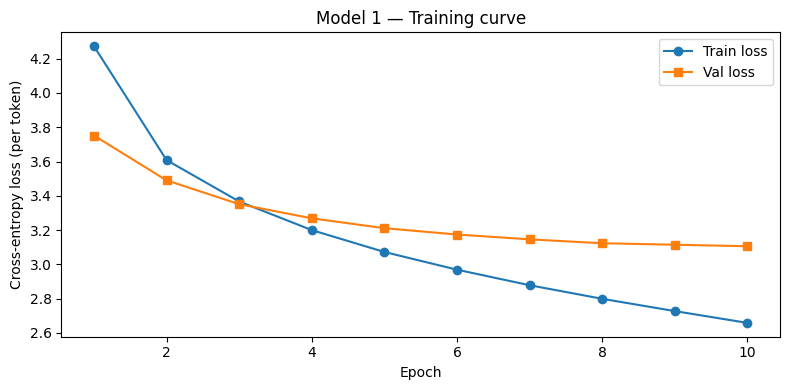

Loaded best checkpoint from epoch 10  (val_loss=3.1059)


In [46]:
# ── Loss curve ────────────────────────────────────────────────────────────────
epochs_range = range(1, len(history1['train_loss']) + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range, history1['train_loss'], label='Train loss', marker='o')
ax.plot(epochs_range, history1['val_loss'],   label='Val loss',   marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss (per token)')
ax.set_title('Model 1 — Training curve')
ax.legend()
plt.tight_layout()
plt.show()

# ── Reload best checkpoint ────────────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
encoder1.load_state_dict(ckpt['encoder_state'])
decoder1.load_state_dict(ckpt['decoder_state'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]}  (val_loss={ckpt["val_loss"]:.4f})')

## 8. Evaluation — BLEU-1 to BLEU-4 + ROUGE-L

**BLEU** counts n-gram overlap between the generated caption and the reference captions.
Higher n-gram order = harder to achieve, more sensitive to fluency.

**ROUGE-L** measures the length of the Longest Common Subsequence (LCS) between
hypothesis and reference. Unlike BLEU, it does not require n-grams to be contiguous —
it rewards capturing the overall narrative structure even when word order differs slightly.
It is reported as an F1 score (harmonic mean of LCS-precision and LCS-recall).

ROUGE-L complements BLEU well: a model that generates fluent but generic captions can
score well on BLEU-1 while scoring lower on ROUGE-L, exposing the difference.

**Expected ranges for this dataset and architecture:**
| Metric | Rough expectation |
|---|---|
| BLEU-1  | 0.45 – 0.60 |
| BLEU-2  | 0.25 – 0.40 |
| BLEU-3  | 0.15 – 0.28 |
| BLEU-4  | 0.08 – 0.18 |
| ROUGE-L | 0.30 – 0.50 |

These are approximate — VizWiz is harder than MSCOCO because images are blurry/occluded.

In [55]:
def generate_captions_for_loader(encoder, decoder, loader, device,
                                  beam_width=3, max_len=30):
    """
    Run beam search over every image in a DataLoader.

    Returns
    -------
    hypotheses : List[List[str]]        — one generated caption per sample
    references : List[List[List[str]]]  — shape required by corpus_bleu
    """
    encoder.eval()
    decoder.eval()

    hypotheses = []
    references = []

    with torch.no_grad():
        for images, captions, lengths in tqdm(loader, desc='Generating captions'):
            images   = images.to(device)
            captions = captions.to(device)

            features = encoder(images)   # (B, embed_size)

            for i in range(features.size(0)):
                feat = features[i].unsqueeze(0)   # (1, embed_size)

                pred_tokens = decoder.generate(feat, max_len=max_len, beam_width=beam_width)
                pred_words  = [idx2word.get(t, '<UNK>') for t in pred_tokens]
                hypotheses.append(pred_words)

                ref_tokens = captions[i].tolist()
                ref_words  = []
                for t in ref_tokens:
                    if t in (PAD_IDX, SOS_IDX):
                        continue
                    if t == EOS_IDX:
                        break
                    ref_words.append(idx2word.get(t, '<UNK>'))
                references.append([ref_words])

    return hypotheses, references


def compute_bleu_scores(hypotheses, references):
    """BLEU-1 through BLEU-4 via corpus_bleu."""
    smoother = SmoothingFunction().method1
    bleu1 = corpus_bleu(references, hypotheses,
                        weights=(1, 0, 0, 0), smoothing_function=smoother)
    bleu2 = corpus_bleu(references, hypotheses,
                        weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)
    bleu3 = corpus_bleu(references, hypotheses,
                        weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoother)
    bleu4 = corpus_bleu(references, hypotheses,
                        weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)
    return bleu1, bleu2, bleu3, bleu4


def compute_rouge_l(hypotheses, references):
    """
    Corpus-level ROUGE-L F1, averaged across all test samples.

    ROUGE-L rewards capturing the narrative structure of a sentence via the
    Longest Common Subsequence — contiguous n-gram matches are not required.
    corpus_bleu aggregates internally; rouge_scorer does not, so we average
    per-sample F1 scores manually (standard practice in captioning literature).
    """
    scorer   = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    total_f1 = 0.0

    for hyp_words, ref_list in zip(hypotheses, references):
        hyp_str  = ' '.join(hyp_words)
        ref_str  = ' '.join(ref_list[0])   # one reference per sample in the loader
        score    = scorer.score(ref_str, hyp_str)
        total_f1 += score['rougeL'].fmeasure

    return total_f1 / len(hypotheses) if hypotheses else 0.0


# ── Run evaluation on test split ──────────────────────────────────────────────
print('Generating captions on test split (beam_width=3) ...')
hyps1, refs1 = generate_captions_for_loader(
    encoder1, decoder1, test_loader, DEVICE, beam_width=BEAM_WIDTH
)

b1, b2, b3, b4 = compute_bleu_scores(hyps1, refs1)
rouge_l        = compute_rouge_l(hyps1, refs1)

print('\n' + '='*42)
print('  Model 1 — Evaluation (test set)')
print('='*42)
print(f'  BLEU-1  : {b1:.4f}')
print(f'  BLEU-2  : {b2:.4f}')
print(f'  BLEU-3  : {b3:.4f}')
print(f'  BLEU-4  : {b4:.4f}')
print(f'  ROUGE-L : {rouge_l:.4f}')
print('='*42)

Generating captions on test split (beam_width=3) ...


Generating captions:   0%|          | 0/118 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c5ad2b349a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/tmp/ipykernel_1604/1210984897.py", line 14, in _safe_is_alive
  File "/tmp/ipykernel_1604/2376932012.py", line 14, in _safe_is_alive
  File "/tmp/ipykernel_1604/2376932012.py", line 14, in _safe_is_alive
  File "/tmp/ipykernel_1604/2376932012.py", line 14, in _safe_is_alive
  [Previous line repeated 965 more times]
RecursionError: maximum recursion depth exceeded



  Model 1 — Evaluation (test set)
  BLEU-1  : 0.2282
  BLEU-2  : 0.1726
  BLEU-3  : 0.1477
  BLEU-4  : 0.1337
  ROUGE-L : 0.2657


## 9. Visual inspection — generated vs. reference captions

Numbers alone (BLEU) don't tell you whether the model is generating reasonable English or
hallucinating nonsense. Looking at real predictions helps you identify failure modes:
- Is the model stuck repeating the same phrase?
- Does it describe objects that aren't in the image?
- Does the language sound fluent even when the content is wrong?

We show 10 random images from the test set. For each one:
- The image itself (de-normalised back to visible colours)
- **Generated:** what our model said
- **Reference 1:** one of the 5 human captions (the one stored in the test batch)

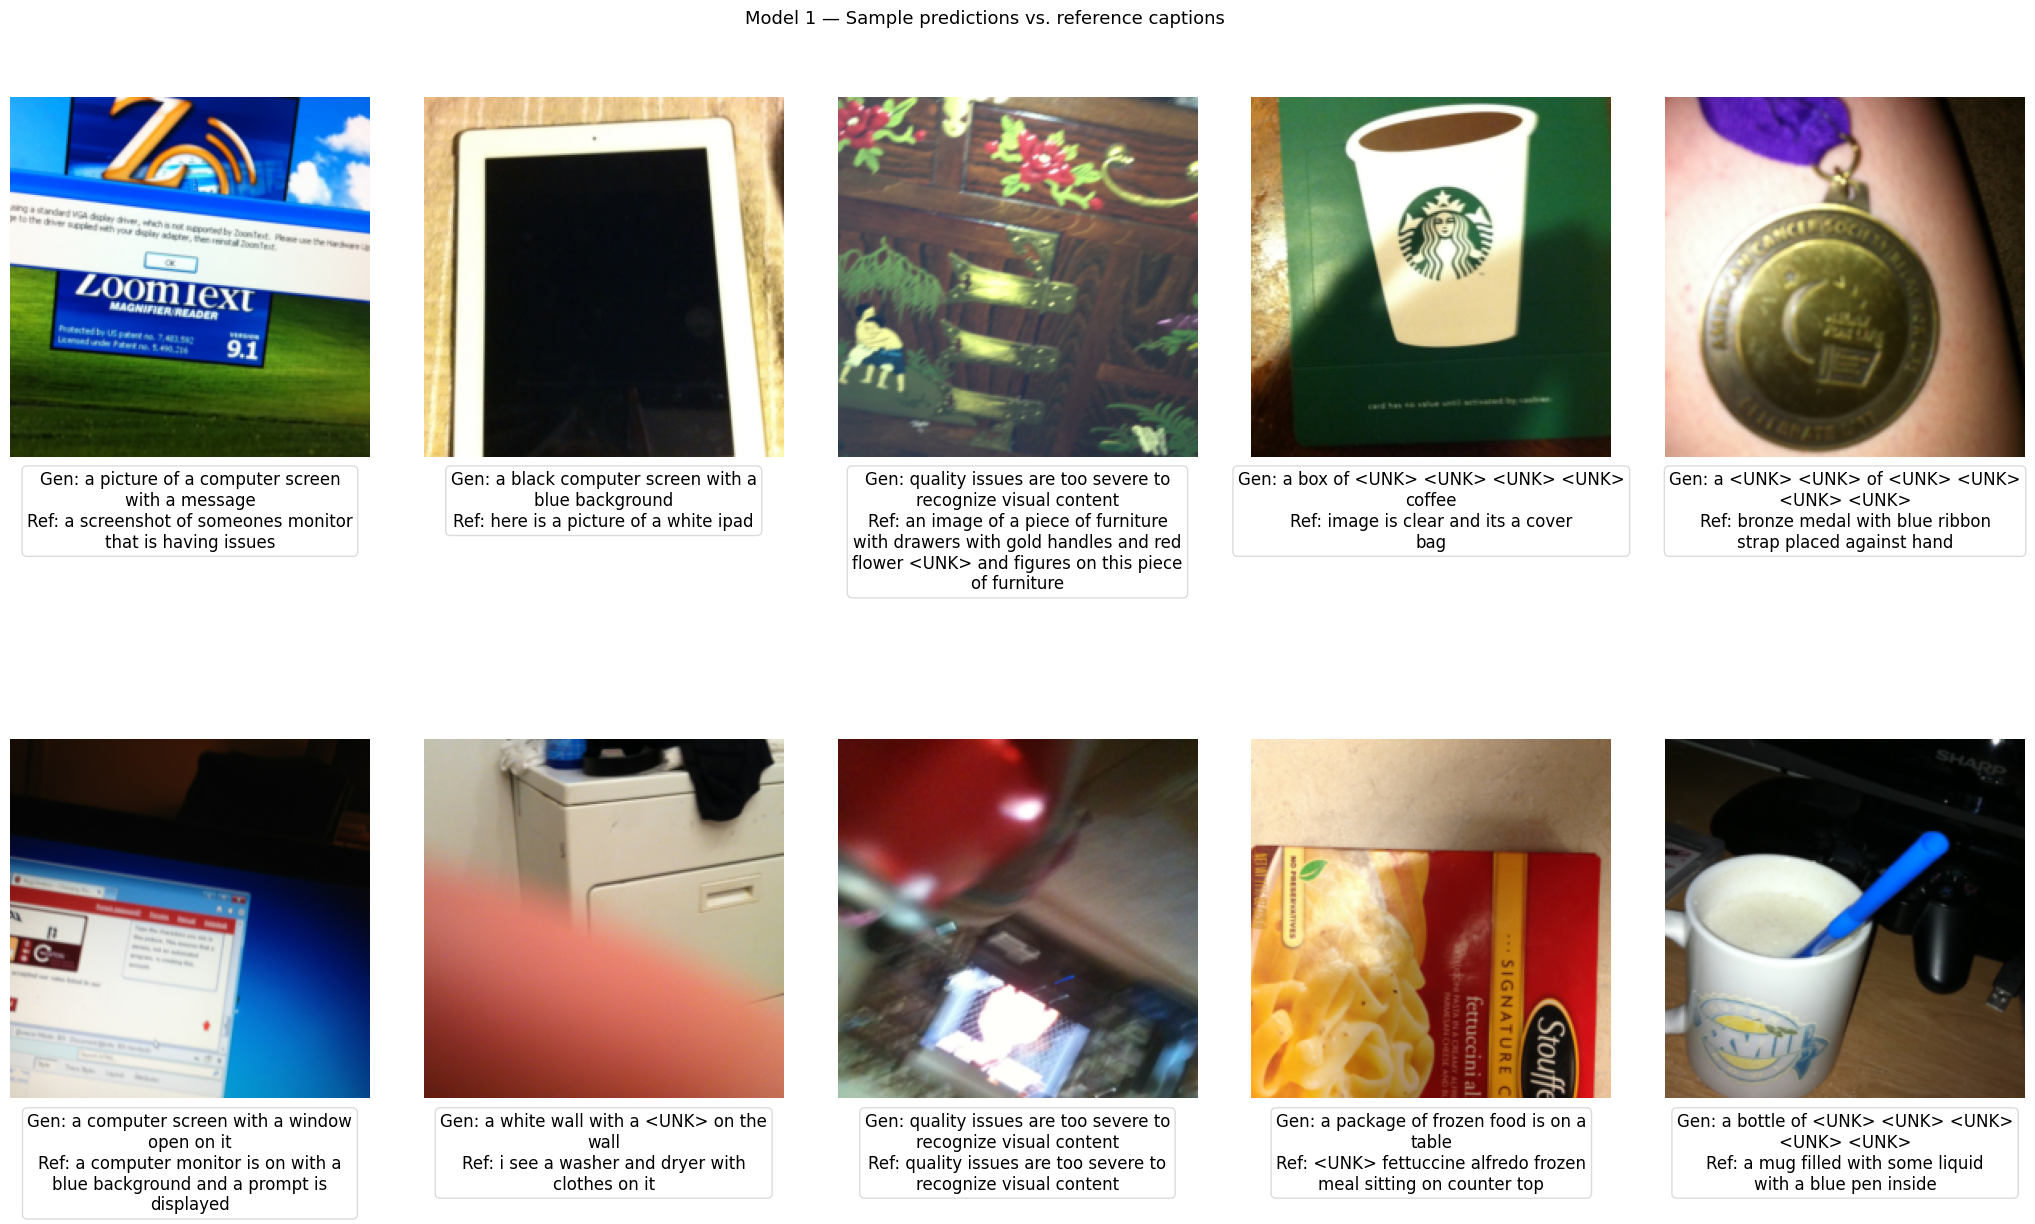

In [41]:
def show_predictions(encoder, decoder, dataset, device,
                     n_samples=10, beam_width=3, seed=42):
    encoder.eval()
    decoder.eval()

    _mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    _std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    rng     = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n_samples)

    # Extra vertical space per row to fit captions below each image
    fig, axes = plt.subplots(2, 5, figsize=(26, 12))

    with torch.no_grad():
        for ax, idx in zip(axes.flat, indices):
            image_tensor, caption_tensor = dataset[idx]

            # Generate caption
            feat        = encoder(image_tensor.unsqueeze(0).to(device))
            pred_tokens = decoder.generate(feat, beam_width=beam_width)
            pred_words  = [idx2word.get(t, '<UNK>') for t in pred_tokens]

            # Decode reference caption
            ref_words = []
            for t in caption_tensor.tolist():
                if t in (PAD_IDX, SOS_IDX):
                    continue
                if t == EOS_IDX:
                    break
                ref_words.append(idx2word.get(t, '<UNK>'))

            img_show = (image_tensor * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()

            ax.imshow(img_show)
            ax.axis('off')

            gen_str = ' '.join(pred_words) if pred_words else '(empty)'
            ref_str = ' '.join(ref_words)  if ref_words  else '(empty)'

            # Wrap text manually to avoid overflow
            import textwrap
            gen_wrapped = '\n'.join(textwrap.wrap(f'Gen: {gen_str}', width=38))
            ref_wrapped = '\n'.join(textwrap.wrap(f'Ref: {ref_str}', width=38))
            caption_text = f'{gen_wrapped}\n{ref_wrapped}'

            # Place text BELOW the image, outside the axes
            ax.text(
                0.5, -0.04,          # x=center, y=just below axes
                caption_text,
                transform=ax.transAxes,
                fontsize=12,
                ha='center',
                va='top',
                wrap=False,          # already wrapped manually
                color='black',
                bbox=dict(           # subtle background box for readability
                    boxstyle='round,pad=0.3',
                    facecolor='white',
                    alpha=0.8,
                    edgecolor='lightgray'
                )
            )

    plt.suptitle('Model 1 — Sample predictions vs. reference captions', fontsize=13)

    # Key fix: add bottom margin so captions don't get clipped
    plt.subplots_adjust(
        hspace=0.55,   # vertical space between rows
        wspace=0.15,   # horizontal space between columns
        bottom=0.05,
        top=0.93
    )

    plt.show()


show_predictions(encoder1, decoder1, test_dataset, DEVICE, n_samples=10, beam_width=BEAM_WIDTH)

---
# Group Discussion Summary

> *Fill in after the Phase 2 group meeting.*
>
> - What architectures did each teammate try?
> - What worked? What did not, and why?
> - What patterns emerged across experiments?
> - How did the discussion inform your Model 2 design?

---
# Model 2 — Phase 3 (Refined Architecture)

> **Describe changes made based on group discussion.**  
> Be explicit: what did you change, why, and what insight from Phase 2 drove that decision.

In [42]:
# TODO: Model 2 architecture (encoder + decoder)
pass

### Model 2 — Training

In [43]:
# TODO: training loop for Model 2
# Save checkpoints to MY_CHECKPTS / 'model2_epoch{e}.pth'
pass

### Model 2 — Evaluation & comparison vs. Model 1

In [44]:
# TODO: BLEU scores for Model 2 + side-by-side comparison table with Model 1
pass